In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

COLORS  = {"Control Campaign": "#4C72B0", "Test Campaign": "#DD8452"}
PALETTE = list(COLORS.values())
sns.set_theme(style="whitegrid", font_scale=1.05)

df = pd.read_parquet('../data/processed/cleaned_data.parquet')

# Названия групп с заглавной буквы (Control / Test)
df["campaign_name"] = df["campaign_name"].str.strip().str.title()
display(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   campaign_name      59 non-null     str           
 1   date               59 non-null     datetime64[us]
 2   spend_usd          59 non-null     int64         
 3   of_impressions     59 non-null     int64         
 4   reach              59 non-null     int64         
 5   of_website_clicks  59 non-null     int64         
 6   of_searches        59 non-null     int64         
 7   of_view_content    59 non-null     int64         
 8   of_add_to_cart     59 non-null     int64         
 9   of_purchase        59 non-null     int64         
dtypes: datetime64[us](1), int64(8), str(1)
memory usage: 5.6 KB


None

,campaign_name,date,spend_usd,of_impressions,reach,of_website_clicks,of_searches,of_view_content,of_add_to_cart,of_purchase
0,Control Campaign,2019-08-01,2280,82702,56930,7016,2290,2159,1819,618
1,Control Campaign,2019-08-02,1757,121040,102513,8110,2033,1841,1219,511
2,Control Campaign,2019-08-03,2343,131711,110862,6508,1737,1549,1134,372
3,Control Campaign,2019-08-04,1940,72878,61235,3065,1042,982,1183,340
4,Control Campaign,2019-08-06,3083,109076,87998,4028,1709,1249,784,764


In [18]:
# KPI

df["ctr"] = df["of_website_clicks"] / df["of_impressions"] * 100   # %
df["cr"]  = df["of_purchase"]       / df["of_website_clicks"] * 100 # %
df["cpa"] = df["spend_usd"]         / df["of_purchase"]             # USD per purchase
df["roas"]= df["of_purchase"]       / df["spend_usd"]               # purchases per USD

In [19]:
# Описательная статистика

# Словари графиков и таблиц для сохранения в html-файл
eda_figs = {}
eda_tables = {}

RAW_METRICS = [
    "spend_usd", "of_impressions", "reach",
    "of_website_clicks", "of_searches",
    "of_view_content", "of_add_to_cart", "of_purchase",
]
KPI_METRICS = ["ctr", "cr", "cpa", "roas"]
ALL_METRICS = RAW_METRICS + KPI_METRICS

print("=" * 65)
print("DATASET INFO")
print("=" * 65)
print(df.groupby("campaign_name").size().rename("rows").to_string())
print(f"\nДата: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Всего строк: {len(df)}\n")

print("=" * 65)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ГРУППАМ")
print("=" * 65)
desc = (
    df.groupby("campaign_name")[ALL_METRICS]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)
print(desc.to_string())

# Сводная таблица: Control vs Test + delta
print("\n" + "=" * 65)
print("СРАВНЕНИЕ СРЕДНИХ (Control vs Test)")
print("=" * 65)
summary = df.groupby("campaign_name")[ALL_METRICS].mean().T.round(2)
summary.columns.name = None
summary["delta"]   = (summary["Test Campaign"] - summary["Control Campaign"]).round(2)
summary["delta_%"] = ((summary["Test Campaign"] - summary["Control Campaign"])
                      / summary["Control Campaign"] * 100).round(1)
print(summary.to_string())

DATASET INFO
campaign_name
Control Campaign    29
Test Campaign       30

Дата: 2019-08-01 → 2019-08-30
Всего строк: 59

ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ГРУППАМ
                 spend_usd                             of_impressions                                        reach                                   of_website_clicks                              of_searches                             of_view_content                            of_add_to_cart                            of_purchase                             ctr                               cr                             cpa                            roas                         
                      mean  median     std   min   max           mean    median       std    min     max      mean   median       std    min     max              mean  median      std   min   max        mean  median     std   min   max            mean  median     std  min   max           mean  median     std  min   max        mean median     std  min  max

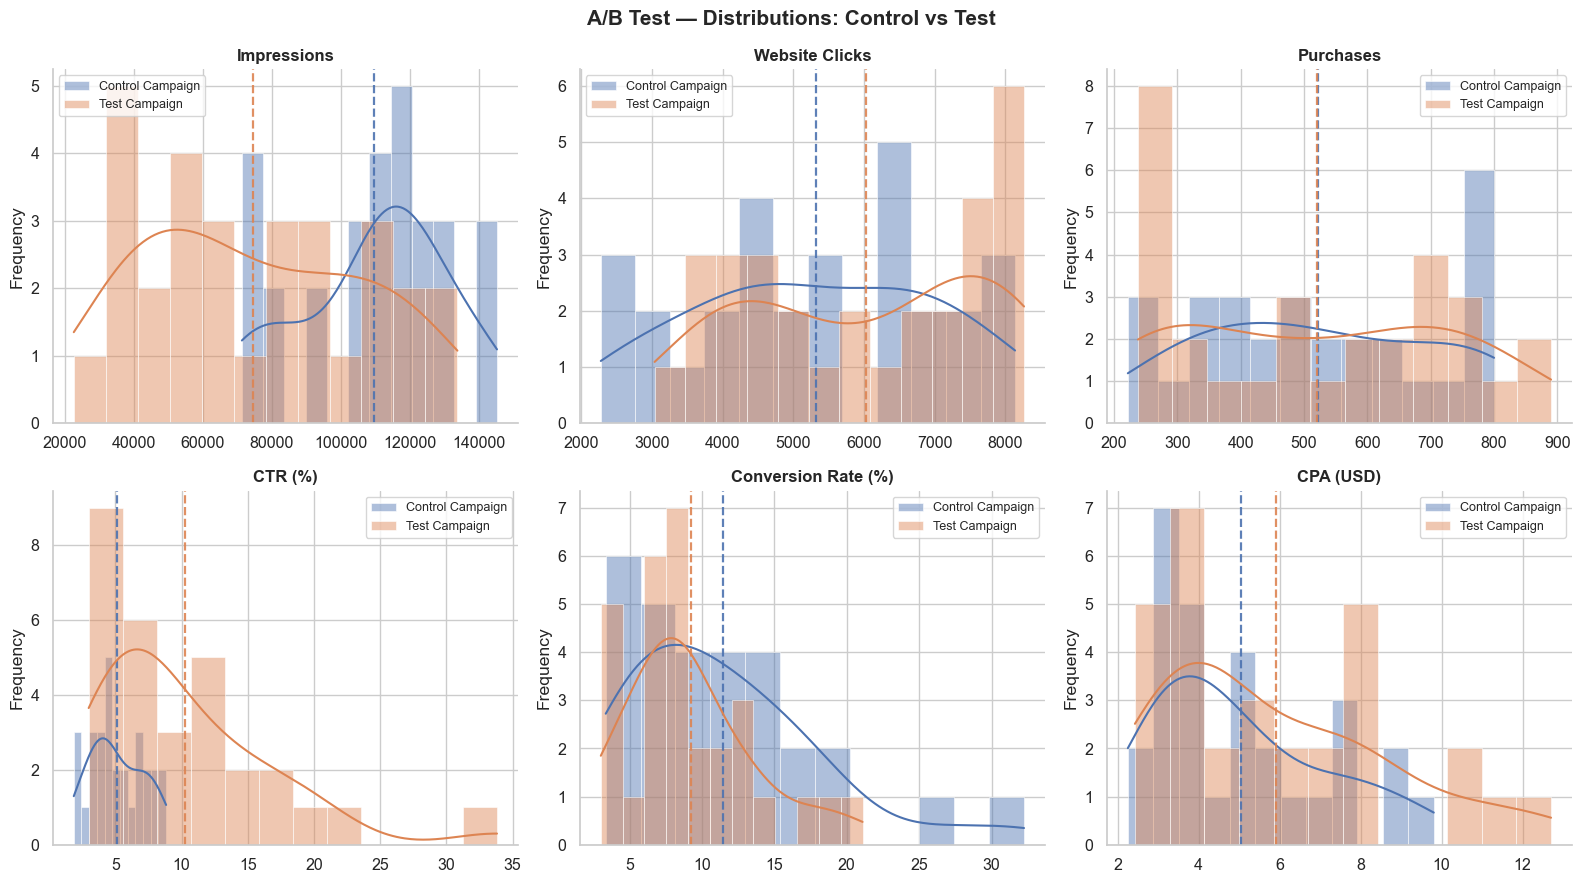

In [20]:
# Гистограммы + KDE

plot_cfg = {
    "of_impressions":    "Impressions",
    "of_website_clicks": "Website Clicks",
    "of_purchase":       "Purchases",
    "ctr":               "CTR (%)",
    "cr":                "Conversion Rate (%)",
    "cpa":               "CPA (USD)",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("A/B Test — Distributions: Control vs Test",
             fontsize=15, fontweight="bold")

for ax, (col, label) in zip(axes.flat, plot_cfg.items()):
    for group, color in COLORS.items():
        data = df[df["campaign_name"] == group][col].dropna()
        sns.histplot(data, ax=ax, color=color, label=group,
                     kde=True, alpha=0.45, bins=12, edgecolor="white", linewidth=0.4)
        ax.axvline(data.mean(), color=color, linestyle="--",
                   linewidth=1.6, alpha=0.9)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\Artem\AppData\Local\Temp\ipykernel_29904\3841475367.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Artem\AppData\Local\Temp\ipykernel_29904\3841475367.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Artem\AppData\Local\Temp\ipykernel_29904\3841475367.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Artem\AppData\Local\Temp\ipykernel_29904\3841475367.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

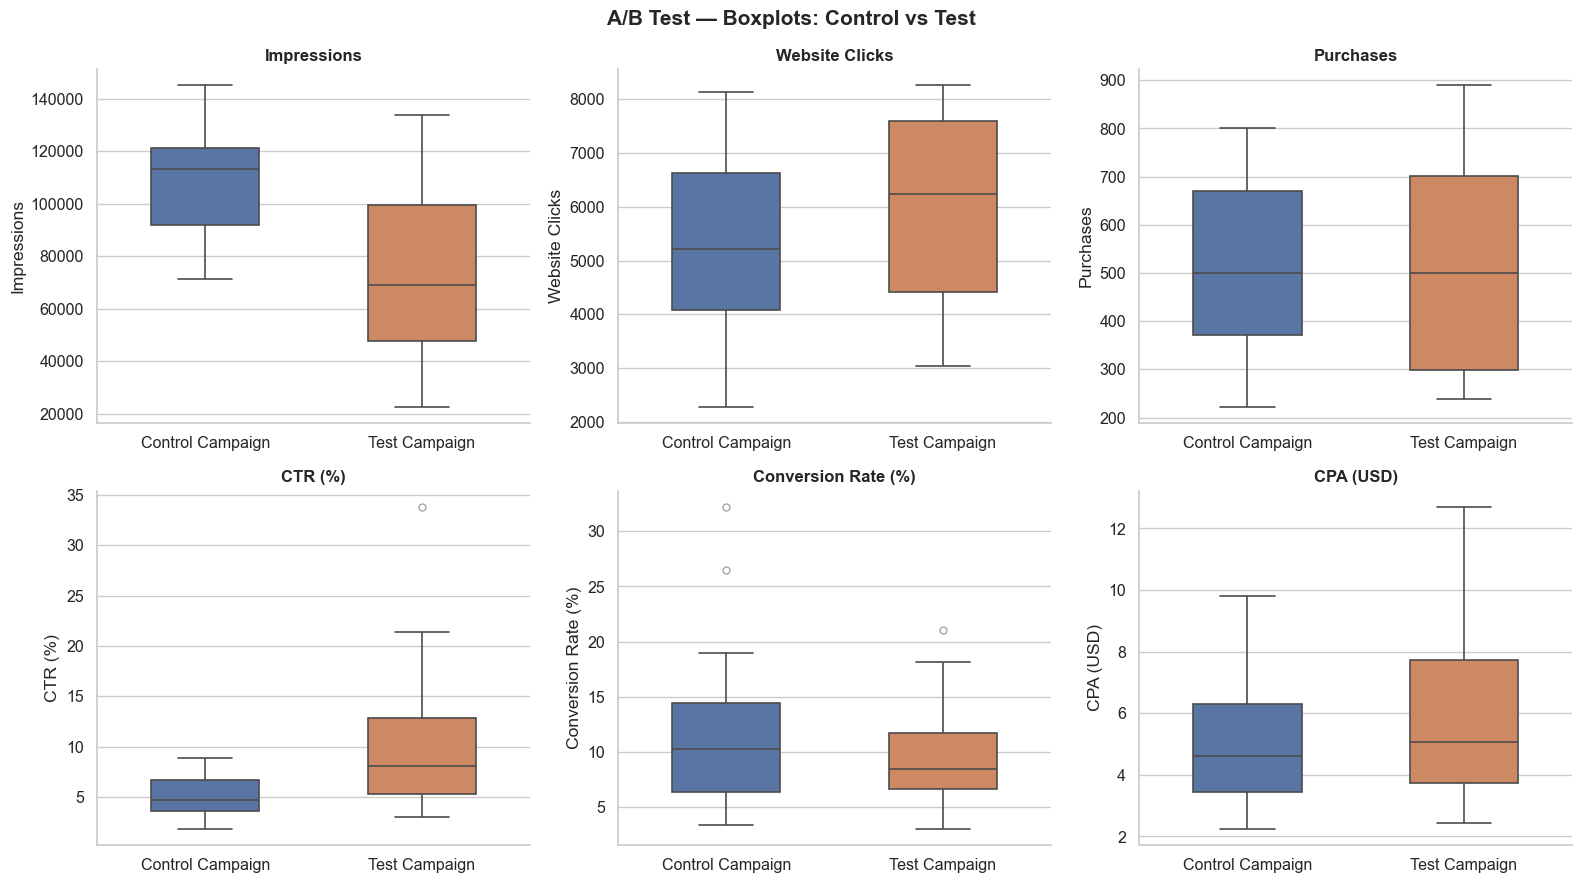

In [21]:
# Boxplots

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("A/B Test — Boxplots: Control vs Test",
             fontsize=15, fontweight="bold")

for ax, (col, label) in zip(axes.flat, plot_cfg.items()):
    sns.boxplot(
        data=df, x="campaign_name", y=col, ax=ax,
        palette=COLORS, order=["Control Campaign", "Test Campaign"],
        width=0.5, linewidth=1.2, flierprops=dict(marker="o", markersize=5, alpha=0.5),
    )
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

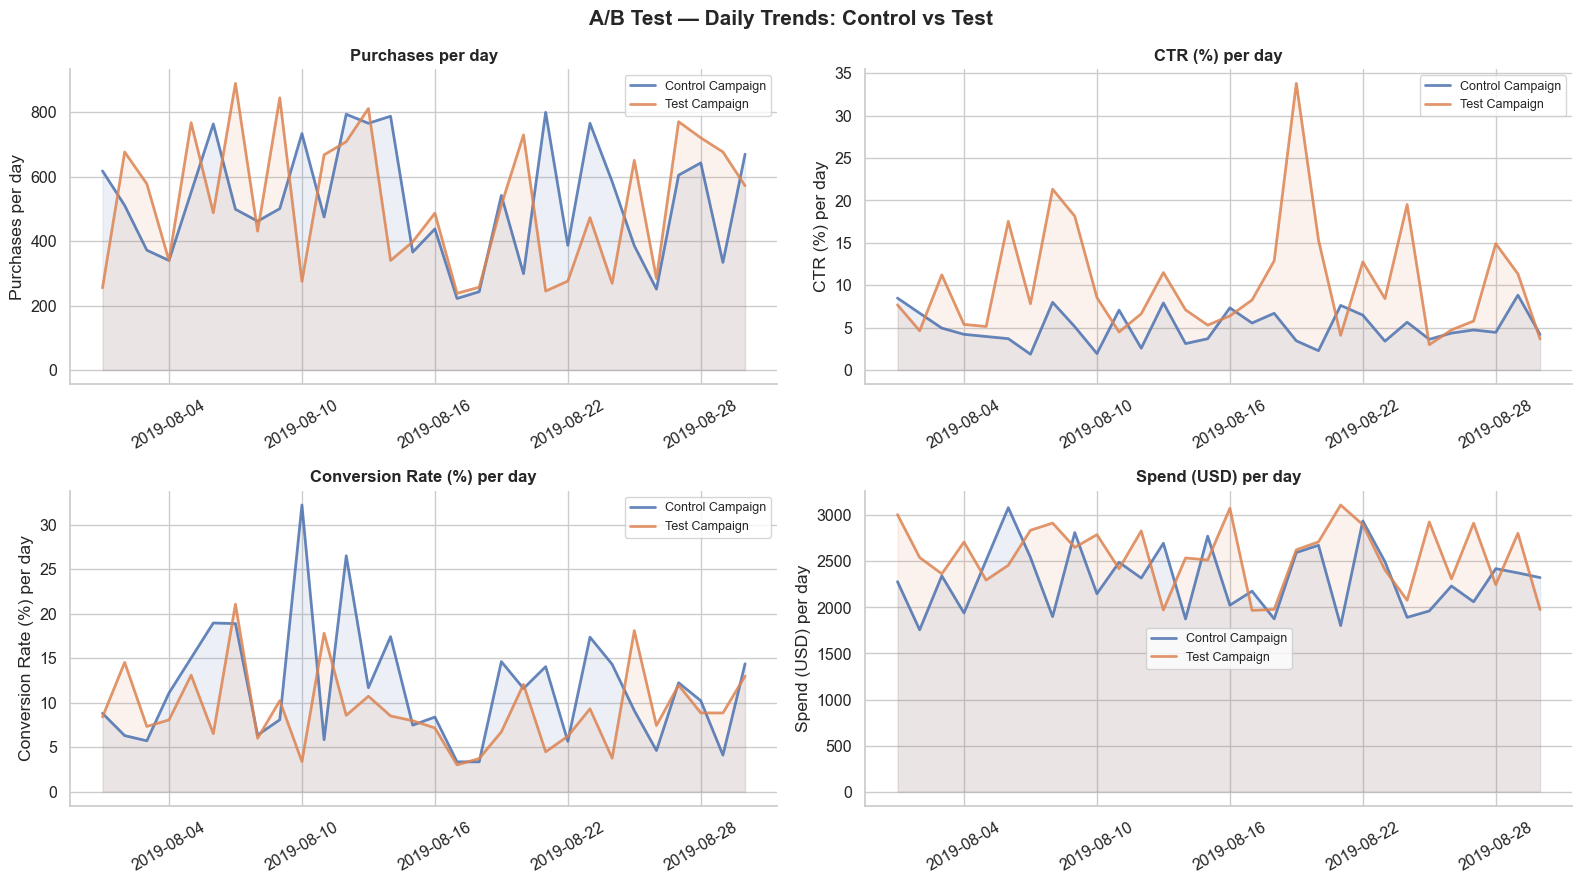

In [22]:
# Временной тренд

trend_metrics = {
    "of_purchase":       "Purchases per day",
    "ctr":               "CTR (%) per day",
    "cr":                "Conversion Rate (%) per day",
    "spend_usd":         "Spend (USD) per day",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("A/B Test — Daily Trends: Control vs Test",
             fontsize=15, fontweight="bold")

for ax, (col, label) in zip(axes.flat, trend_metrics.items()):
    for group, color in COLORS.items():
        data = (df[df["campaign_name"] == group]
                .sort_values("date")
                .set_index("date")[col])
        ax.plot(data.index, data.values, color=color,
                label=group, linewidth=2, alpha=0.85)
        ax.fill_between(data.index, data.values, alpha=0.1, color=color)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

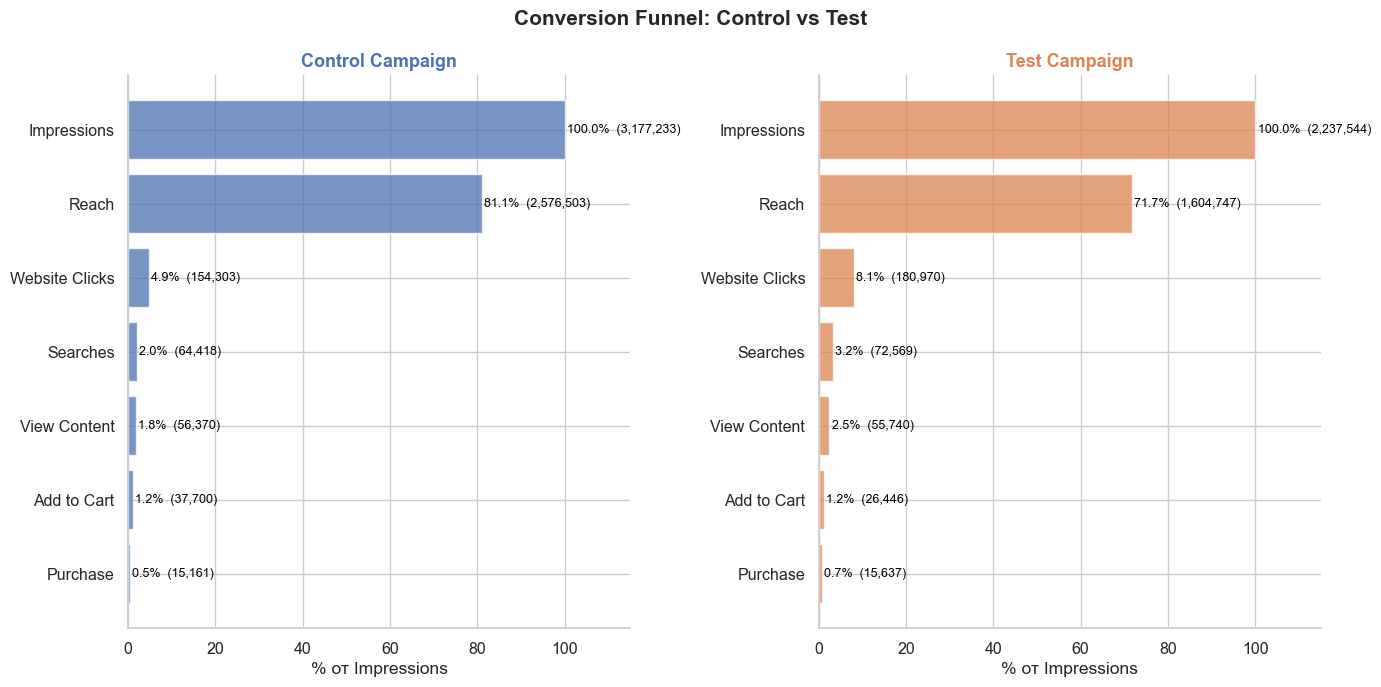

In [23]:
# Воронка конверсии

funnel_cols = [
    "of_impressions", "reach",
    "of_website_clicks", "of_searches",
    "of_view_content", "of_add_to_cart", "of_purchase",
]
funnel_labels = [
    "Impressions", "Reach",
    "Website Clicks", "Searches",
    "View Content", "Add to Cart", "Purchase",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle("Conversion Funnel: Control vs Test",
             fontsize=15, fontweight="bold")

for ax, (group, color) in zip(axes, COLORS.items()):
    values = df[df["campaign_name"] == group][funnel_cols].sum().values
    pcts   = values / values[0] * 100  # % от верха воронки

    bars = ax.barh(funnel_labels[::-1], pcts[::-1],
                   color=color, alpha=0.75, edgecolor="white")
    for bar, pct, val in zip(bars, pcts[::-1], values[::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%  ({val:,.0f})",
                va="center", fontsize=9, color="black")
    ax.set_title(group, fontsize=13, fontweight="bold", color=color)
    ax.set_xlabel("% от Impressions")
    ax.set_xlim(0, 115)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

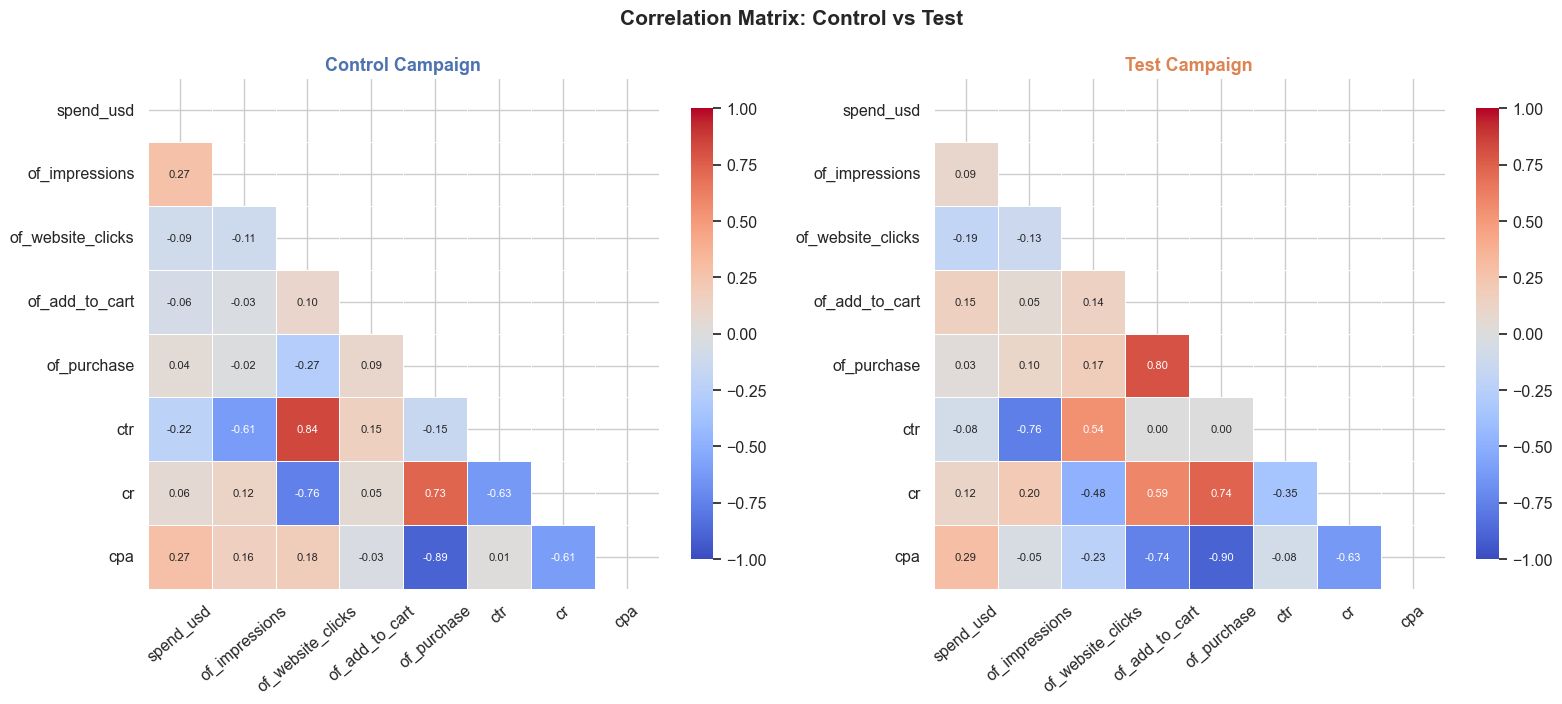

In [24]:
# Корреляционная матрица

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Correlation Matrix: Control vs Test",
             fontsize=15, fontweight="bold")

corr_cols = ["spend_usd", "of_impressions", "of_website_clicks",
             "of_add_to_cart", "of_purchase", "ctr", "cr", "cpa"]

for ax, (group, color) in zip(axes, COLORS.items()):
    corr = df[df["campaign_name"] == group][corr_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))  # скрыть верхний треугольник
    sns.heatmap(
        corr, ax=ax, mask=mask, annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        linewidths=0.5, square=True, cbar_kws={"shrink": 0.8},
        annot_kws={"size": 8},
    )
    ax.set_title(group, fontsize=13, fontweight="bold", color=color)
    ax.tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

In [25]:
# Нормальность (Shapiro-Wilk)

print("\n" + "=" * 65)
print("SHAPIRO-WILK TEST  (p > 0.05 → нормальное распределение)")
print("=" * 65)
check_cols = ["of_purchase", "of_website_clicks", "ctr", "cr", "cpa"]
rows = []
for col in check_cols:
    for group in ["Control", "Test"]:
        data = df[df["campaign_name"] == group][col].dropna()
        stat, p = stats.shapiro(data)
        rows.append({
            "metric": col, "group": group,
            "stat": round(stat, 4), "p_value": round(p, 4),
            "normal": "✓ да" if p > 0.05 else "✗ нет",
        })
print(pd.DataFrame(rows).to_string(index=False))
print("\n→ Если большинство метрик НЕ нормальны — используй Mann-Whitney U в 02_ab_test.ipynb")


SHAPIRO-WILK TEST  (p > 0.05 → нормальное распределение)
           metric   group  stat  p_value normal
      of_purchase Control   NaN      NaN  ✗ нет
      of_purchase    Test   NaN      NaN  ✗ нет
of_website_clicks Control   NaN      NaN  ✗ нет
of_website_clicks    Test   NaN      NaN  ✗ нет
              ctr Control   NaN      NaN  ✗ нет
              ctr    Test   NaN      NaN  ✗ нет
               cr Control   NaN      NaN  ✗ нет
               cr    Test   NaN      NaN  ✗ нет
              cpa Control   NaN      NaN  ✗ нет
              cpa    Test   NaN      NaN  ✗ нет

→ Если большинство метрик НЕ нормальны — используй Mann-Whitney U в 02_ab_test.ipynb


C:\Users\Artem\AppData\Local\Temp\ipykernel_29904\3690214369.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = stats.shapiro(data)
